# Task 3: Cognitive Load and the Data-Ink Ratio (`car_crashes.csv`, `tips.csv`)

Applying Sweller's Cognitive Load Theory (Intrinsic, Extraneous, Germane) and Tufte's Data-Ink Ratio principles to vehicle collision data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_crashes = pd.read_csv('data/car_crashes.csv')
print(f"Total rows: {len(df_crashes)}")
df_crashes.head()

Total rows: 51


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


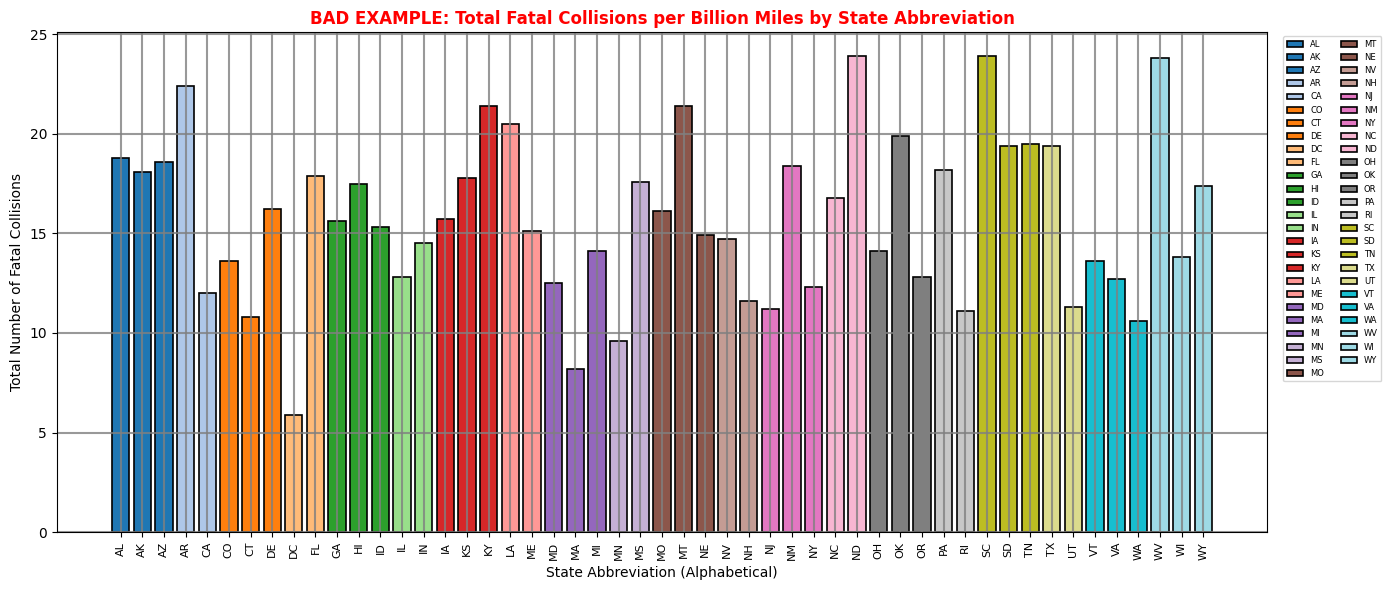

In [2]:
# 1. Deliberately overloaded chart with maximal extraneous load
fig, ax = plt.subplots(figsize=(14, 6))

# Rainbow colors, 51 entries
colors = plt.cm.tab20(np.linspace(0, 1, len(df_crashes)))
bars = ax.bar(df_crashes['abbrev'], df_crashes['total'], color=colors, edgecolor='black', linewidth=1.2)

# Unreadable rotated labels
ax.set_xticks(range(len(df_crashes)))
ax.set_xticklabels(df_crashes['abbrev'], rotation=90, fontsize=8)

# Heavy dual gridlines
ax.grid(True, which='both', linestyle='-', linewidth=1.5, color='gray', alpha=0.8)

# Cluttered title stating axes
ax.set_title("BAD EXAMPLE: Total Fatal Collisions per Billion Miles by State Abbreviation", 
             fontsize=12, fontweight='bold', color='red')
ax.set_xlabel("State Abbreviation (Alphabetical)", fontsize=10)
ax.set_ylabel("Total Number of Fatal Collisions", fontsize=10)

# Unusable 51-item legend
ax.legend(bars, df_crashes['abbrev'], bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2, fontsize=6)

plt.tight_layout()
fig.savefig("bad_example_overloaded.png", dpi=300, bbox_inches="tight")
plt.show()

### 2. Cognitive Load Classification of Visual Elements

| Visual Element | Load Type | Justification |
| :--- | :--- | :--- |
| **51 Bar Heights (`total`)** | **Intrinsic** | The core data measurements required to understand crash differences. |
| **51 Unique Rainbow Colors** | **Extraneous** | Distracts from magnitude; implies categorical distinctions that do not exist. |
| **51-Item Legend** | **Extraneous** | Redundant lookup table; state names are already on the horizontal axis. |
| **Heavy Black Box Frame / Spines** | **Extraneous** | Encloses the chart without encoding any data. |
| **Dense High-Contrast Dual Grid** | **Extraneous** | Creates visual clutter and competes with bar silhouettes. |
| **Rotated State Labels** | **Extraneous** | Forces neck craning and slows lexical decoding. |
| **Alphabetical Ordering** | **Extraneous** | Forces readers to perform a visual search to locate high and low crash states. |
| **Subtle Zero Baseline** | **Germane** | Essential anchor confirming bar lengths represent honest proportional values. |

---

### Data-Ink Ratio Estimation & Working

$$\text{Data-Ink Ratio} = \frac{\text{Data-Ink}}{\text{Total Ink}}$$

- **Data-Ink Marks:** 51 bar fills encoding numerical values = **51 data units**.
- **Non-Data / Extraneous Ink Marks:**
  - 51 black bar outlines: 51
  - 51 legend color patches + 51 text entries: 102
  - 4 heavy bounding box spines: 4
  - 2 sets of dense dual gridlines (~30 lines): 30
  - 51 rotated axis ticks and labels: 102
  - Axis titles: 2
  - **Total Non-Data Marks:** $\approx 291$ units.
- **Estimated Total Ink:** $51 + 291 = 342$ units.
- **Calculated Ratio:** $\frac{51}{342} \approx \mathbf{0.15}$ (only 15% of the visual ink conveys data).

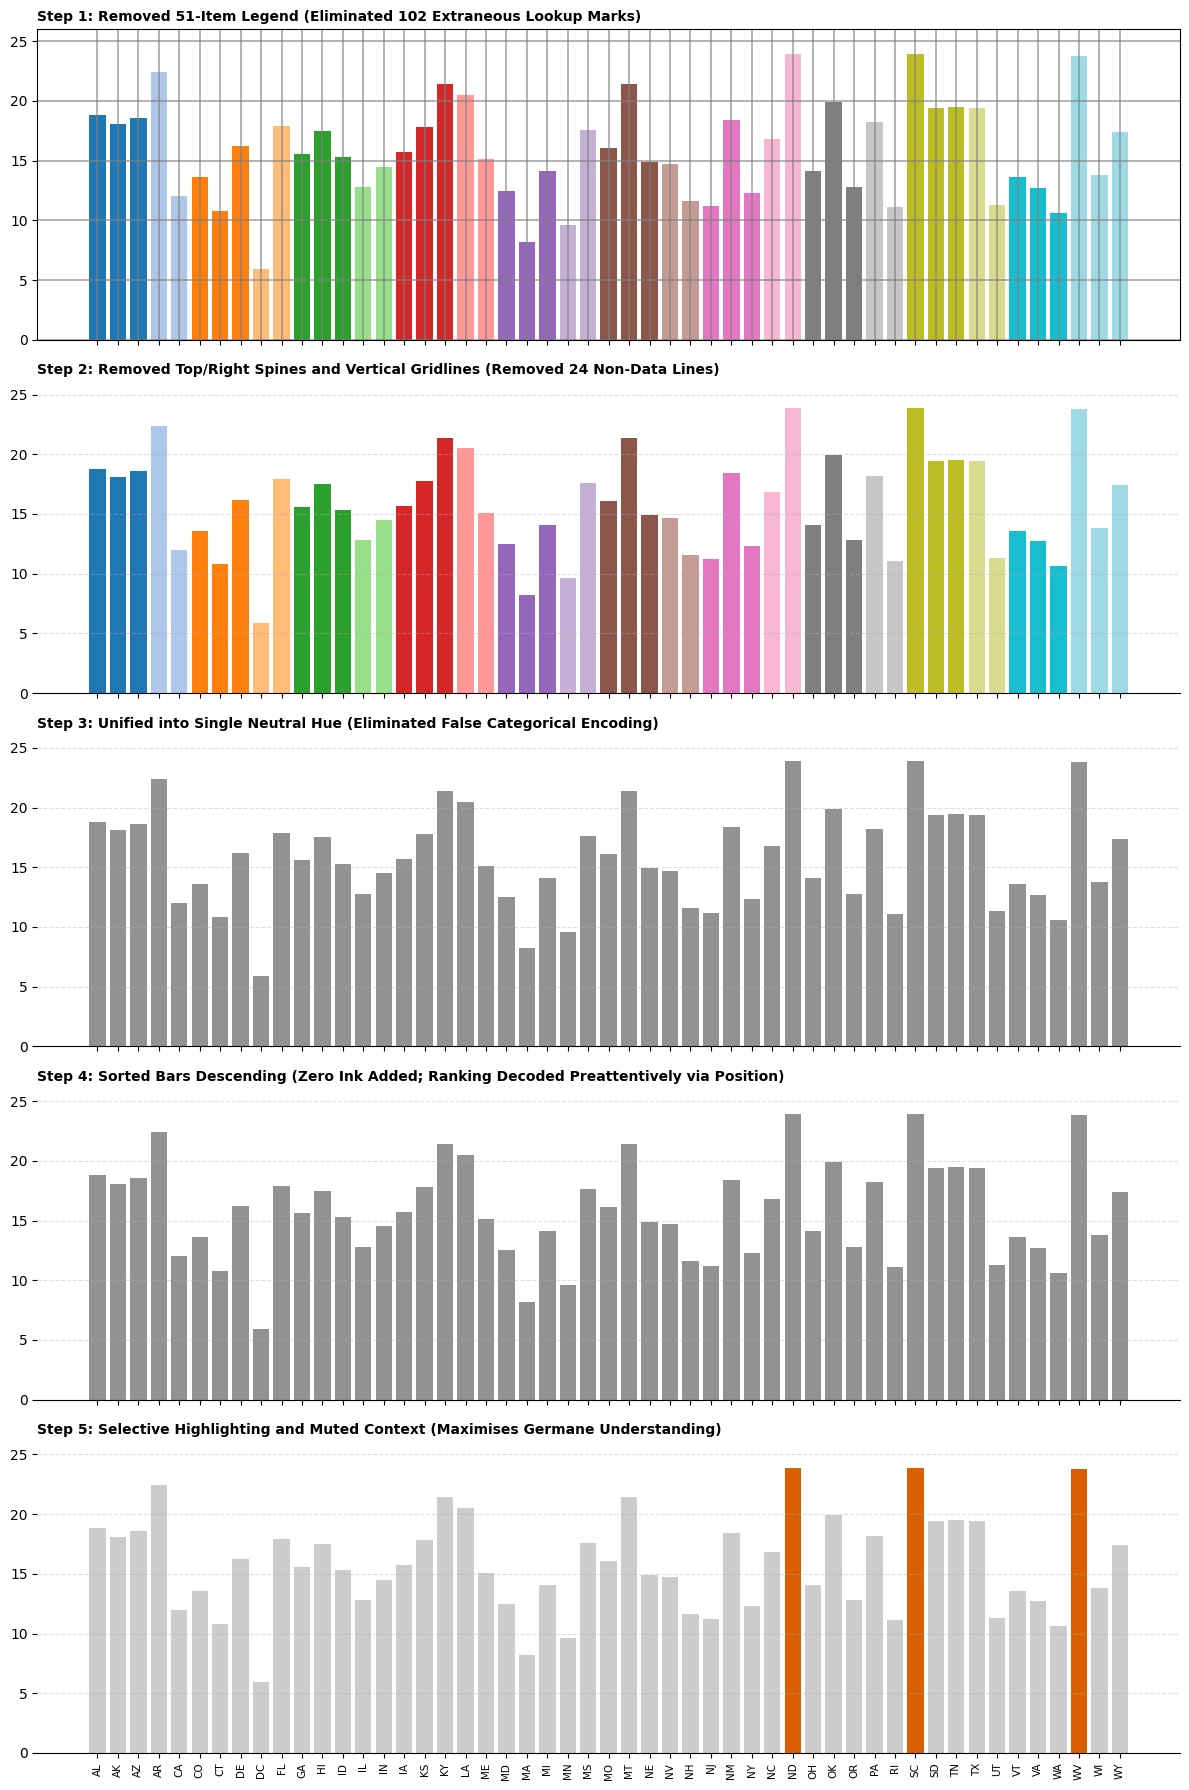

In [3]:
# Sort data descending by collision rate
df_sorted = df_crashes.sort_values('total', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

# Step 1: Remove legend
axes[0].bar(df_crashes['abbrev'], df_crashes['total'], color=colors)
axes[0].grid(True, linestyle='-', linewidth=1.2, color='gray', alpha=0.7)
axes[0].set_title("Step 1: Removed 51-Item Legend (Eliminated 102 Extraneous Lookup Marks)", fontsize=10, fontweight='bold', loc='left')

# Step 2: Remove frame spines and vertical gridlines
axes[1].bar(df_crashes['abbrev'], df_crashes['total'], color=colors)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)
for side in ('top', 'right', 'left'):
    axes[1].spines[side].set_visible(False)
axes[1].set_title("Step 2: Removed Top/Right Spines and Vertical Gridlines (Removed 24 Non-Data Lines)", fontsize=10, fontweight='bold', loc='left')

# Step 3: Drop to a single neutral hue
axes[2].bar(df_crashes['abbrev'], df_crashes['total'], color='#7f7f7f', alpha=0.85)
axes[2].grid(True, axis='y', linestyle='--', alpha=0.4)
for side in ('top', 'right', 'left'):
    axes[2].spines[side].set_visible(False)
axes[2].set_title("Step 3: Unified into Single Neutral Hue (Eliminated False Categorical Encoding)", fontsize=10, fontweight='bold', loc='left')

# Step 4: Sort bars by value
axes[3].bar(df_sorted['abbrev'], df_sorted['total'], color='#7f7f7f', alpha=0.85)
axes[3].grid(True, axis='y', linestyle='--', alpha=0.4)
for side in ('top', 'right', 'left'):
    axes[3].spines[side].set_visible(False)
axes[3].set_title("Step 4: Sorted Bars Descending (Zero Ink Added; Ranking Decoded Preattentively via Position)", fontsize=10, fontweight='bold', loc='left')

# Step 5: Purposeful highlighting and selective direct labelling
bar_cols = ['#d95f02' if x in ['ND', 'SC', 'WV'] else '#cccccc' for x in df_sorted['abbrev']]
axes[4].bar(df_sorted['abbrev'], df_sorted['total'], color=bar_cols)
axes[4].grid(True, axis='y', linestyle='--', alpha=0.4)
for side in ('top', 'right', 'left'):
    axes[4].spines[side].set_visible(False)
axes[4].set_title("Step 5: Selective Highlighting and Muted Context (Maximises Germane Understanding)", fontsize=10, fontweight='bold', loc='left')

for ax in axes:
    ax.set_ylim(bottom=0, top=26)
    ax.tick_params(axis='x', rotation=90, labelsize=7.5)

plt.tight_layout()
plt.show()

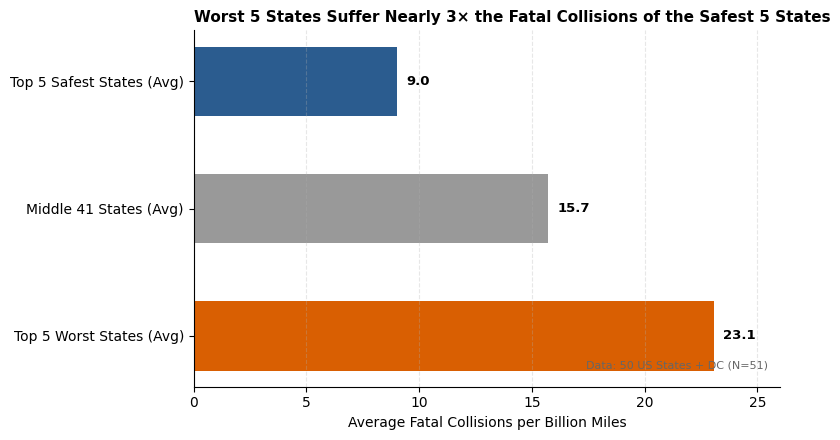

In [4]:
# Chunking strategy: Top 5 states isolated, bottom 5 states isolated, middle 41 states pooled
top5 = df_crashes.sort_values('total', ascending=False).head(5)
bottom5 = df_crashes.sort_values('total', ascending=False).tail(5)
middle_val = df_crashes.sort_values('total', ascending=False).iloc[5:-5]['total'].mean()

chunked_df = pd.DataFrame([
    {'group': 'Top 5 Worst States (Avg)', 'val': top5['total'].mean(), 'color': '#d95f02'},
    {'group': 'Middle 41 States (Avg)', 'val': middle_val, 'color': '#999999'},
    {'group': 'Top 5 Safest States (Avg)', 'val': bottom5['total'].mean(), 'color': '#2b5c8f'}
])

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(chunked_df['group'], chunked_df['val'], color=chunked_df['color'], height=0.55)

ax.set_title("Worst 5 States Suffer Nearly 3× the Fatal Collisions of the Safest 5 States", 
             loc='left', fontsize=11, fontweight='bold')
ax.set_xlabel("Average Fatal Collisions per Billion Miles")
ax.set_xlim(0, 26)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.grid(True, axis='x', linestyle='--', alpha=0.3)

# Direct data values
for b in bars:
    w = b.get_width()
    ax.text(w + 0.4, b.get_y() + b.get_height()/2, f"{w:.1f}", va='center', fontweight='bold', fontsize=9.5)

ax.text(0.98, 0.05, "Data: 50 US States + DC (N=51)", transform=ax.transAxes, ha='right', fontsize=8, color='#666666')
plt.tight_layout()
plt.show()

### 4. Working Memory Chunking Evaluation
- **Chunking Strategy Chosen:** Aggregated the 51 states into **3 macro chunks**: Safest 5 States, Middle 41 Baseline, and Worst 5 States.
- **Cognitive Benefit:** Working memory handles only 3 chunks simultaneously ($3 \le 4 \pm 1$), allowing immediate comprehension of the disparity without visual fatigue.
- **The Trade-Off (Cost):** Slicing into 3 aggregate chunks completely conceals within-group variance, individual state identities, and regional geographic clustering.

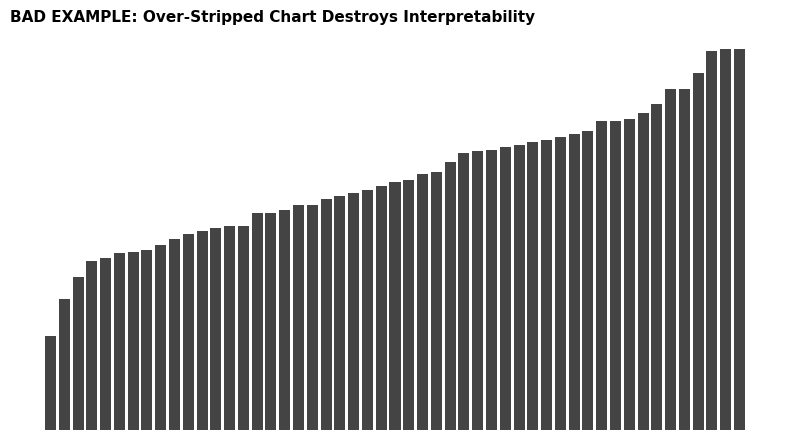

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(df_sorted)), df_sorted['total'], color='#444444', width=0.8)

# Strip literally everything
ax.set_xticks([])
ax.set_yticks([])
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_visible(False)

ax.set_title("BAD EXAMPLE: Over-Stripped Chart Destroys Interpretability", fontsize=11, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()

### Stopping Rule for Data-Ink Reduction
> **Stopping Rule:** Remove ink until removing one additional mark impairs the reader's ability to decode numeric values, identify comparative scale, or extract the intended finding.

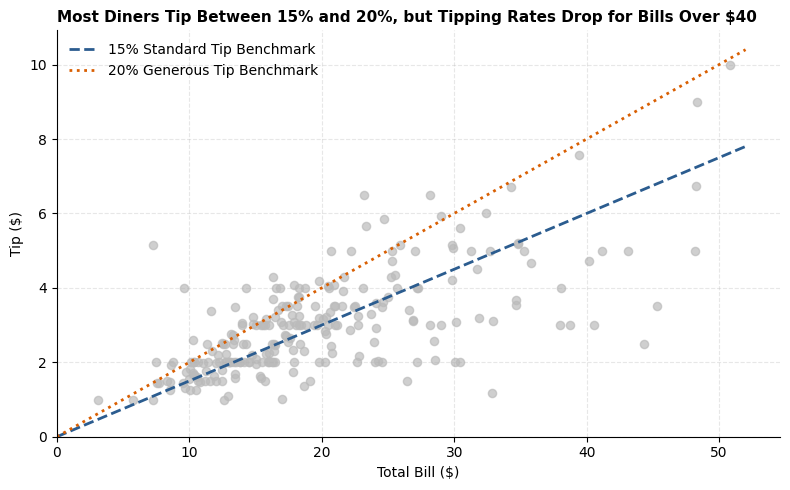

In [6]:
df_tips = pd.read_csv('data/tips.csv')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_tips['total_bill'], df_tips['tip'], color='#bbbbbb', alpha=0.7, s=35)

# Add reference lines that add ink but dramatically reduce cognitive calculation effort
x_vals = np.linspace(0, 52, 100)
ax.plot(x_vals, 0.15 * x_vals, color='#2b5c8f', linestyle='--', lw=2, label='15% Standard Tip Benchmark')
ax.plot(x_vals, 0.20 * x_vals, color='#d95f02', linestyle=':', lw=2, label='20% Generous Tip Benchmark')

ax.set_title("Most Diners Tip Between 15% and 20%, but Tipping Rates Drop for Bills Over $40", 
             loc='left', fontsize=11, fontweight='bold')
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.legend(frameon=False, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

### Why "Maximise Data-Ink" Is a Heuristic, Not an Absolute Law
In the `tips.csv` chart, adding the two reference lines ($15\%$ and $20\%$) **added non-data ink**. 
However, without those lines, the reader must mentally divide $y$ by $x$ for each individual point to determine whether a tip was generous or poor. Adding deliberate reference ink performs that arithmetic for the human visual system, substituting expensive working-memory calculations with instantaneous preattentive spatial positioning.